# 03 · Cycling vs Quiescent (Annulus–Disk Mixture)

**Purpose:** call each cell as **cycling** or **quiescent** by modeling the circle geometry from **02**. We fit a **2-component Gaussian mixture** on the **radius**: the inner **disk** (quiescent) and the outer **ring** (cycling).

### What this notebook does

1. Load `mm_timecourse.h5ad` (must contain `phase_theta` and `radius` from **02**).
2. Fit a **1D GMM** on `radius` → get per-cell `cycling_prob` and a binary `cycling_call`.
3. Visualize cycling on **PHATE/t-SNE** and check **radius vs θ**.
4. Summarize cycling fraction by **time** (`week`, `timesimple`) and **stage** (`stage_label`); export tables/plots.

### Outputs

* `obs["cycling_prob"]` ∈ [0,1] and `obs["cycling_call"]` ∈ {0,1}
* Figures:

  * `fig03_radius_mixture.png` (mixture fit intuition)
  * `fig03_*_cycling_prob.png`, `fig03_*_cycling_call.png` (embeddings)
  * `fig03_cycling_by_{key}.png` (bar charts per group)
  * `fig03_radius_vs_theta.png` (sanity check)
* Tables:

  * `tab03_cycling_by_{key}.csv` (group summaries)

**Validation checklist**

* The mixture’s higher-mean component corresponds to the **ring** (cycling).
* Cycling probability enriches in regions of embeddings expected to contain proliferating cells.
* Group summaries show biologically sensible trends (e.g., late timepoints ↑ cycling).

In [6]:
from pathlib import Path
import yaml, sys
import numpy as np, pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# project root
def repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for _ in range(8):
        if (p/"configs/params.yaml").exists(): return p
        p = p.parent
    raise FileNotFoundError("configs/params.yaml not found.")
BASE = repo_root()
P = yaml.safe_load(open(BASE/"configs/params.yaml")) or {}
ANNDATA = BASE / P.get("paths", {}).get("anndata", "data/interim/mm_timecourse.h5ad")
FIGDIR  = BASE / P.get("paths", {}).get("figures", "outputs/figures")
TABDIR  = BASE / P.get("paths", {}).get("tables", "outputs/tables")
FIGDIR.mkdir(parents=True, exist_ok=True); TABDIR.mkdir(parents=True, exist_ok=True)

adata = ad.read_h5ad(ANNDATA)
print(adata)
assert "radius" in adata.obs and "phase_theta" in adata.obs, "Run notebook 02 first."


AnnData object with n_obs × n_vars = 3891 × 52638
    obs: 'sampleID', 'CODING_BASES', 'INTERGENIC_BASES', 'INTRONIC_BASES', 'MEDIAN_3PRIME_BIAS', 'MEDIAN_5PRIME_BIAS', 'MEDIAN_5PRIME_TO_3PRIME_BIAS', 'MEDIAN_CV_COVERAGE', 'NUM_R1_TRANSCRIPT_STRAND_READS', 'NUM_R2_TRANSCRIPT_STRAND_READS', 'NUM_UNEXPLAINED_READS', 'PCT_CODING_BASES', 'PCT_INTERGENIC_BASES', 'PCT_INTRONIC_BASES', 'PCT_MRNA_BASES', 'PCT_R1_TRANSCRIPT_STRAND_READS', 'PCT_R2_TRANSCRIPT_STRAND_READS', 'PCT_RIBOSOMAL_BASES', 'PCT_USABLE_BASES', 'PCT_UTR_BASES', 'PF_ALIGNED_BASES', 'PF_BASES', 'RIBOSOMAL_BASES', 'UTR_BASES', 'isDup', 'expCount', 'expMeanHK', 'expPropHK', 'expMeanMt', 'expPropMt', 'cell_id', 'week', 'timesimple', 'mouseID', 'plateID', 'typeID', 'clusterK12', 'tSNE_1', 'tSNE_2', 'phate_1', 'phate_2', 'stage_label', 'stage_bin', 'S_cc', 'G2M_cc', 'phase_cc', 'S_res', 'G2M_res', 'phase_theta', 'radius'
    var: 'geneID', 'ensgID', 'geneSymbol', 'length'
    uns: 'cc_space', 'log1p', 'markers', 'markers_used'
    

cycling fraction: 0.959


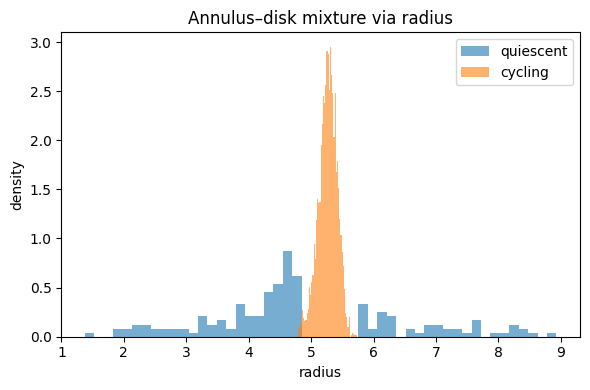

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/figures/fig03_radius_mixture.png
[write] updated /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/data/interim/mm_timecourse.h5ad


In [7]:
# Fit a 2-component GMM to radius: disk (quiescent) vs ring (cycling)
r = adata.obs["radius"].to_numpy().reshape(-1,1)

# sensible init: kmeans++ via sklearn; but just let GMM handle
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=0)
gmm.fit(r)
probs = gmm.predict_proba(r)

# identify which component is the ring (higher mean radius)
means = gmm.means_.ravel()
ring_comp = int(np.argmax(means))
cycling_prob = probs[:, ring_comp]

adata.obs["cycling_prob"] = cycling_prob
adata.obs["cycling_call"] = (cycling_prob >= 0.5).astype(int)

print("cycling fraction:", adata.obs["cycling_call"].mean().round(3))

# visualize
plt.figure(figsize=(6,4))
plt.hist(r[adata.obs["cycling_call"].values==0], bins=50, alpha=0.6, label="quiescent", density=True)
plt.hist(r[adata.obs["cycling_call"].values==1], bins=50, alpha=0.6, label="cycling", density=True)
plt.xlabel("radius"); plt.ylabel("density"); plt.title("Annulus–disk mixture via radius")
plt.legend(); plt.tight_layout()
out = FIGDIR/"fig03_radius_mixture.png"; plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
print("[saved]", out)

adata.write(ANNDATA); print("[write] updated", ANNDATA)


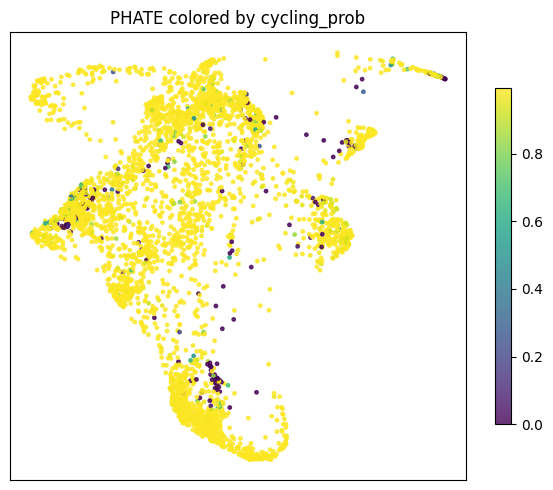

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/figures/fig03_phate_cycling_prob.png


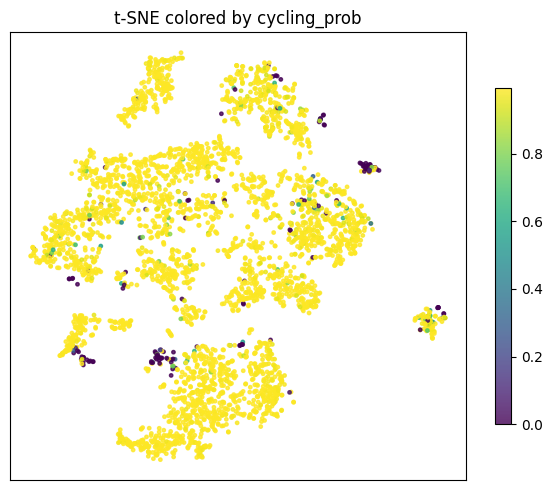

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/figures/fig03_tsne_cycling_prob.png


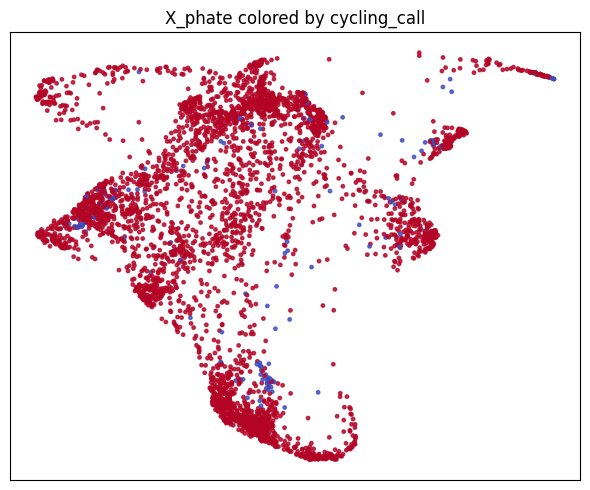

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/figures/fig03_x_phate_cycling_call.png


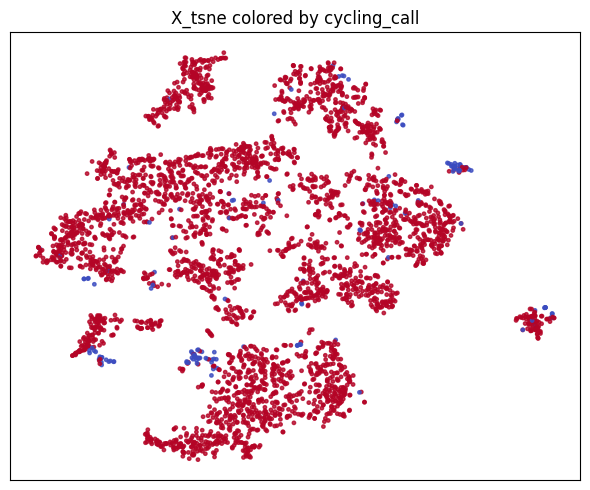

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/figures/fig03_x_tsne_cycling_call.png


In [8]:
# Embeddings colored by cycling probability/call
import numpy as np, matplotlib.pyplot as plt

def plot_embed(emb_key, color, title, fname):
    if emb_key not in adata.obsm:
        print(f"[skip] {emb_key} not in .obsm"); return
    M = adata.obsm[emb_key]
    c = adata.obs[color].to_numpy()
    plt.figure(figsize=(6,5))
    sc = plt.scatter(M[:,0], M[:,1], s=6, c=c, cmap="viridis", alpha=0.8)
    plt.xticks([]); plt.yticks([]); plt.title(title)
    plt.colorbar(sc, shrink=0.75)
    out = FIGDIR / fname
    plt.tight_layout(); plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
    print("[saved]", out)

plot_embed("X_phate", "cycling_prob", "PHATE colored by cycling_prob", "fig03_phate_cycling_prob.png")
plot_embed("X_tsne",  "cycling_prob", "t-SNE colored by cycling_prob",  "fig03_tsne_cycling_prob.png")

# binary call
for emb in ("X_phate","X_tsne"):
    if emb in adata.obsm:
        M = adata.obsm[emb]; c = adata.obs["cycling_call"].to_numpy()
        plt.figure(figsize=(6,5))
        plt.scatter(M[:,0], M[:,1], s=6, c=c, cmap="coolwarm", alpha=0.8)
        plt.xticks([]); plt.yticks([]); plt.title(f"{emb} colored by cycling_call")
        out = FIGDIR / f"fig03_{emb.lower()}_cycling_call.png"
        plt.tight_layout(); plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
        print("[saved]", out)



== timesimple ==


/tmp/ipykernel_75588/4036377381.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(key, dropna=False).agg(


,n,cycling_frac,cycling_prob_mean
timesimple,,,
01_T_early_ND,206,0.980583,0.970450
08_KP_30w_ND,1554,0.973616,0.960552
NaN,505,0.972277,0.959733
04_K_12w_ND,455,0.960440,0.946267
07_KP_20w_ND,538,0.951673,0.935719
06_KP_12w_ND,491,0.924644,0.912641
02_KorKP_early_ND,142,0.859155,0.847851


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/tables/tab03_cycling_by_timesimple.csv


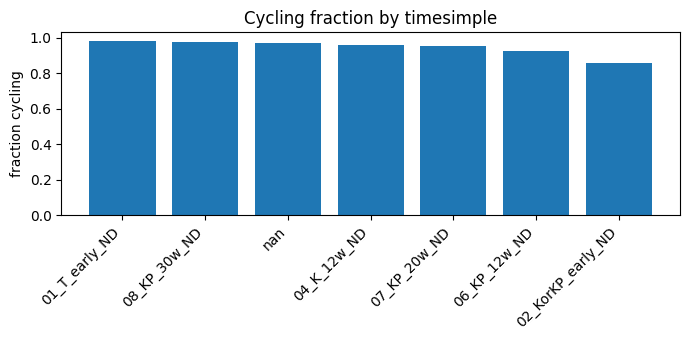

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/figures/fig03_cycling_by_timesimple.png

== week ==


,n,cycling_frac,cycling_prob_mean
week,,,
0,162,0.981481,0.971245
4,44,0.977273,0.967521
30,2059,0.973288,0.960351
20,538,0.951673,0.935719
12,946,0.941860,0.928814
2,142,0.859155,0.847851


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/tables/tab03_cycling_by_week.csv


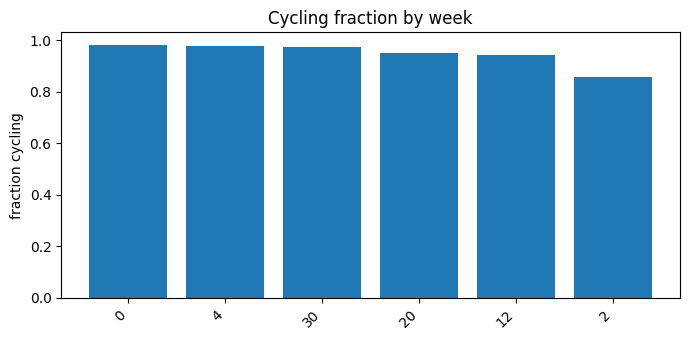

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/figures/fig03_cycling_by_week.png

== stage_label ==


/tmp/ipykernel_75588/4036377381.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(key, dropna=False).agg(


,n,cycling_frac,cycling_prob_mean
stage_label,,,
late,3543,0.961614,0.948190
early,348,0.931034,0.920424


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/tables/tab03_cycling_by_stage_label.csv


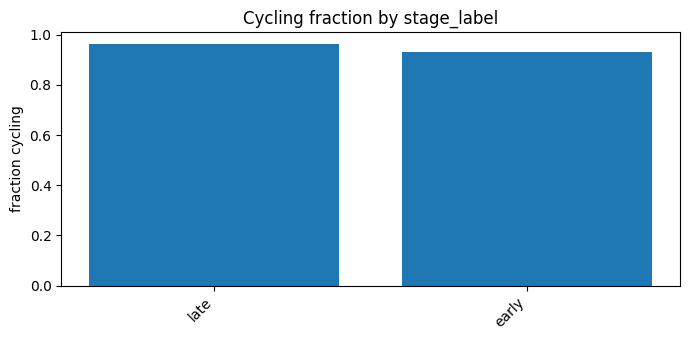

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/figures/fig03_cycling_by_stage_label.png
[write] updated /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/data/interim/mm_timecourse.h5ad


In [9]:
# Summaries of cycling fraction by group(s)
import pandas as pd, numpy as np, matplotlib.pyplot as plt

def summarize_by(key):
    df = adata.obs[[key, "cycling_call", "cycling_prob"]].copy()
    g = df.groupby(key, dropna=False).agg(
        n=("cycling_call","size"),
        cycling_frac=("cycling_call","mean"),
        cycling_prob_mean=("cycling_prob","mean"),
    ).sort_values("cycling_frac", ascending=False)
    return g

for key in ["timesimple", "week", "stage_label"]:
    if key in adata.obs:
        g = summarize_by(key)
        print(f"\n== {key} =="); display(g)
        # save table
        out_csv = TABDIR / f"tab03_cycling_by_{key}.csv"
        g.to_csv(out_csv); print("[saved]", out_csv)
        # bar plot
        plt.figure(figsize=(7,3.5))
        plt.bar(g.index.astype(str), g["cycling_frac"].values)
        plt.title(f"Cycling fraction by {key}"); plt.ylabel("fraction cycling")
        plt.xticks(rotation=45, ha="right"); plt.tight_layout()
        out_fig = FIGDIR / f"fig03_cycling_by_{key}.png"
        plt.savefig(out_fig, dpi=200, bbox_inches="tight"); plt.show()
        print("[saved]", out_fig)

adata.write(ANNDATA); print("[write] updated", ANNDATA)


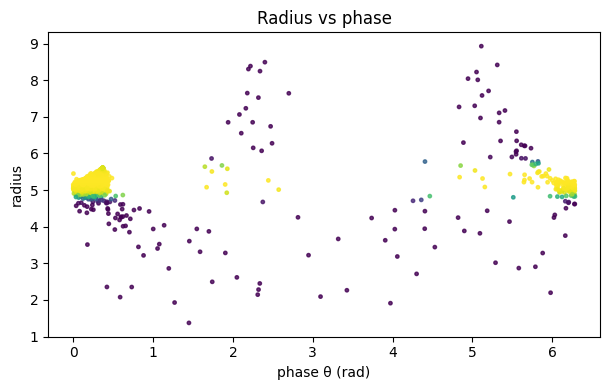

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/outputs/figures/fig03_radius_vs_theta.png


In [10]:
# radius vs phase to see ring vs disk separation
import numpy as np, matplotlib.pyplot as plt
th = adata.obs["phase_theta"].to_numpy()
rad = adata.obs["radius"].to_numpy()
plt.figure(figsize=(6.2,4))
plt.scatter(th, rad, s=6, c=adata.obs["cycling_prob"], cmap="viridis", alpha=0.8)
plt.xlabel("phase θ (rad)"); plt.ylabel("radius"); plt.title("Radius vs phase")
plt.tight_layout(); out = FIGDIR/"fig03_radius_vs_theta.png"
plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
print("[saved]", out)


In [11]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

genes = [g for g in ["Mki67","Top2a","Aurkb","Mcm5","Pcna"] if g in adata.var_names]
print("markers present:", genes)

def mean_by_call(g):
    x = adata[:, g].X
    x = np.asarray(x.toarray() if hasattr(x, "toarray") else x).ravel()
    df = pd.DataFrame({"expr": x, "call": adata.obs["cycling_call"].values})
    return df.groupby("call").expr.mean()

for g in genes:
    print(g, mean_by_call(g))

# correlation with cycling_prob
for g in genes:
    x = adata[:, g].X
    x = np.asarray(x.toarray() if hasattr(x, "toarray") else x).ravel()
    rho = np.corrcoef(x, adata.obs["cycling_prob"])[0,1]
    print(f"corr({g}, cycling_prob) = {rho:.2f}")


markers present: ['Mki67', 'Top2a', 'Aurkb', 'Mcm5', 'Pcna']
Mki67 call
0    0.700963
1    0.012698
Name: expr, dtype: float32
Top2a call
0    0.696595
1    0.012880
Name: expr, dtype: float32
Aurkb call
0    0.432827
1    0.004906
Name: expr, dtype: float32
Mcm5 call
0    0.751872
1    0.081522
Name: expr, dtype: float32
Pcna call
0    0.774657
1    0.325315
Name: expr, dtype: float32
corr(Mki67, cycling_prob) = -0.63
corr(Top2a, cycling_prob) = -0.57
corr(Aurkb, cycling_prob) = -0.53
corr(Mcm5, cycling_prob) = -0.44
corr(Pcna, cycling_prob) = -0.25


In [12]:
rad = adata.obs["radius"].to_numpy()
r0  = np.median(rad)
mad = np.median(np.abs(rad - r0)) * 1.4826
ring_band = np.abs(rad - r0) <= 2.0*mad   # tighten/loosen 1.5–2.5 as needed

adata.obs["cycling_call_robust"] = ring_band.astype(int)
print("fraction (robust):", adata.obs["cycling_call_robust"].mean().round(3))

# agreement with GMM
agree = (adata.obs["cycling_call"] == adata.obs["cycling_call_robust"]).mean()
print("GMM vs robust agreement:", round(agree, 3))


fraction (robust): 0.918
GMM vs robust agreement: 0.959


In [13]:
# --- Relabel GMM components using cell-cycle markers ---
import numpy as np

# responsibilities from your existing GMM fit
probs = gmm.predict_proba(r)   # shape (n_cells, 2)

# build a simple cycling marker score per cell
marker_genes = [g for g in ["Mki67","Top2a","Aurkb","Mcm5","Pcna"] if g in adata.var_names]
assert marker_genes, "No cell-cycle markers found in var_names."

m = np.zeros(adata.n_obs, dtype=float)
for g in marker_genes:
    x = adata[:, g].X
    x = np.asarray(x.toarray() if hasattr(x, "toarray") else x).ravel()
    m += x
# z-score for stability
m = (m - m.mean()) / (m.std() + 1e-8)

# component-wise weighted mean marker signal
comp_marker_means = (probs.T @ m) / probs.sum(axis=0)
cycling_comp = int(np.argmax(comp_marker_means))   # component with higher marker signal = cycling

# final cycling probabilities & calls
cycling_prob = probs[:, cycling_comp]
adata.obs["cycling_prob"] = cycling_prob
adata.obs["cycling_call"] = (cycling_prob >= 0.5).astype(int)

print("component marker means:", comp_marker_means, "| cycling_comp =", cycling_comp)
print("cycling fraction (marker-based):", adata.obs["cycling_call"].mean().round(3))


component marker means: [-0.1280293   2.23007946] | cycling_comp = 1
cycling fraction (marker-based): 0.041


In [14]:
# correlations should now be positive
for g in marker_genes:
    x = adata[:, g].X
    x = np.asarray(x.toarray() if hasattr(x,"toarray") else x).ravel()
    rho = np.corrcoef(x, adata.obs["cycling_prob"])[0,1]
    print(f"corr({g}, cycling_prob) = {rho:.2f}")


corr(Mki67, cycling_prob) = 0.63
corr(Top2a, cycling_prob) = 0.57
corr(Aurkb, cycling_prob) = 0.53
corr(Mcm5, cycling_prob) = 0.44
corr(Pcna, cycling_prob) = 0.25
